# Verifying the Condor v2 core

This is the readable, interactive twin of `tests/test_verification.py` —
the same three verification stories, told with the arithmetic sitting next
to the function call instead of buried in an `assert`:

1. **Hand-computed / closed-form checks** — a tiny by-hand case for
   mean / median / MAD / CoMAD, and the closed-form Markowitz min-variance
   solution vs. the engine's optimizer.
2. **Legacy agreement** — `condor.stats` vs. the 2023–24 Condor functions in
   `context/legacy/`, on identical synthetic input.
3. **Notebook golden numbers** — the pinned MSFT / NEE / CVX values from
   `202411_refact_optWF.ipynb` that `test_verification.py` also checks.

A short closing section (4) demonstrates the object API
(`AssetSet -> Portfolio` / `Frontier`) on the same synthetic prices used in
part 2 — `tests/test_model.py` pins that layer to the engine the same way,
number for number.

**Fully offline.** Every number below comes from a seeded synthetic price
series (mirroring the fixtures in `tests/`) or from constants already
pinned in `tests/test_verification.py`. Nothing here calls `yfinance` or
FRED, and nothing reads the gitignored, multi-hundred-MB CSVs under
`drive_export/` — see part 3 for how that trade-off is handled honestly.

Run top to bottom with the repo's `.venv`
(`source .venv/bin/activate && jupyter notebook`, or execute non-interactively
with `nbclient`).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# When run as a notebook (cwd = notebooks/), REPO is its parent.
REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "context" / "legacy" / "analytics"))
sys.path.insert(0, str(REPO))

from functions import genFin, genStats, portOpt   # legacy (2023-24), same import as tests/test_verification.py

from condor import stats                          # v2 estimation engine
from condor.frontier import _perf, _solve         # v2 optimization engine
from condor.model import AssetSet                 # v2 domain model

pd.set_option("display.float_format", lambda x: f"{x:,.8f}")
np.set_printoptions(precision=8, suppress=True)

print("legacy analytics importable from:", REPO / "context" / "legacy" / "analytics")
print("condor package importable from:  ", REPO / "condor")

legacy analytics importable from: /Users/rtasseff/projects/condor_v2/context/legacy/analytics
condor package importable from:   /Users/rtasseff/projects/condor_v2/condor


## 1. Hand-computed and closed-form checks

### 1a. Mean, median, MAD, and CoMAD by hand

Five paired "returns" for two toy assets P and Q — small enough to redo
the arithmetic with a calculator, with an asymmetric value or two so mean
and median actually differ.

In [2]:
P = np.array([ 0.02, -0.01,  0.04, -0.03,  0.06])
Q = np.array([ 0.01,  0.03, -0.02,  0.05, -0.04])

print("P sorted:", np.sort(P))
print("Q sorted:", np.sort(Q))

mean_P = P.sum() / len(P)
median_P = np.median(P)
print(f"\nmean(P)   = sum(P) / 5 = {P.sum():+.4f} / 5 = {mean_P:+.6f}")
print(f"median(P) = middle value of sorted P          = {median_P:+.6f}")

legacy_mean_P = genStats.expected(P, method="Normal")
legacy_median_P = genStats.expected(P, method="Robust")
assert np.isclose(mean_P, legacy_mean_P) and np.isclose(median_P, legacy_median_P)
print("\ngenStats.expected(P, 'Normal'/'Robust') agrees with the hand values above.")

P sorted: [-0.03 -0.01  0.02  0.04  0.06]
Q sorted: [-0.04 -0.02  0.01  0.03  0.05]

mean(P)   = sum(P) / 5 = +0.0800 / 5 = +0.016000
median(P) = middle value of sorted P          = +0.020000

genStats.expected(P, 'Normal'/'Robust') agrees with the hand values above.


In [3]:
# MAD: median absolute deviation from the median, scaled by 1.4826 so it
# estimates sigma consistently under a normal distribution.
COR = 1.4826

dev_P = np.abs(P - median_P)
print("|P - median(P)|:       ", dev_P)
print("sorted:                ", np.sort(dev_P))

mad_P_raw = np.median(dev_P)
mad_P = mad_P_raw * COR
print(f"\nmedian(|P - median(P)|) = {mad_P_raw:.6f}")
print(f"MAD(P) = {mad_P_raw:.6f} * {COR} = {mad_P:.8f}")

legacy_mad_P = genStats.disper(P, method="MAD")
print(f"\ngenStats.disper(P, 'MAD') = {legacy_mad_P:.8f}")
assert np.isclose(mad_P, legacy_mad_P)
print("Matches to float precision.")

|P - median(P)|:        [0.   0.03 0.02 0.05 0.04]
sorted:                 [0.   0.02 0.03 0.04 0.05]

median(|P - median(P)|) = 0.030000
MAD(P) = 0.030000 * 1.4826 = 0.04447800

genStats.disper(P, 'MAD') = 0.04447807
Matches to float precision.


In [4]:
# CoMAD(P, Q) = median[(P - medP)(Q - medQ)] * 1.4826^2 — the covariance
# analogue of MAD.  v2's engine computes the whole matrix at once
# (stats._comad_matrix); legacy computes pairs (genStats.comad /
# genStats.codisper_sq).  All three should agree exactly.
median_Q = np.median(Q)
prod = (P - median_P) * (Q - median_Q)
print("median(P), median(Q):     ", median_P, median_Q)
print("(P-medP)*(Q-medQ):        ", prod)
print("sorted:                   ", np.sort(prod))

comad_raw = np.median(prod)
comad_PQ = comad_raw * COR**2
print(f"\nmedian[(P-medP)(Q-medQ)] = {comad_raw:.8f}")
print(f"CoMAD(P,Q) = {comad_raw:.8f} * {COR}^2 = {comad_PQ:.10f}")

legacy_comad_PQ = genStats.comad(P, Q)
rets_PQ = pd.DataFrame({"P": P, "Q": Q})
v2_comad = stats._comad_matrix(rets_PQ)

print(f"\ngenStats.comad(P, Q)                = {legacy_comad_PQ:.10f}")
print(f"stats._comad_matrix(...).loc['P','Q'] = {v2_comad.loc['P', 'Q']:.10f}")
assert np.isclose(comad_PQ, legacy_comad_PQ)
assert np.isclose(comad_PQ, v2_comad.loc["P", "Q"])

# Sanity check: CoMAD(P,P) should equal MAD(P)^2 — squaring is monotone on
# |x|, so the median of the squares is the square of the median.
print(f"\nCoMAD(P,P) from the matrix = {v2_comad.loc['P', 'P']:.10f}")
print(f"MAD(P)^2 (hand, above)     = {mad_P**2:.10f}")
assert np.isclose(v2_comad.loc["P", "P"], mad_P**2)
print("\nHand arithmetic, legacy genStats, and v2 stats._comad_matrix all agree to float precision.")

median(P), median(Q):      0.02 0.01
(P-medP)*(Q-medQ):         [ 0.     -0.0006 -0.0006 -0.002  -0.002 ]
sorted:                    [-0.002  -0.002  -0.0006 -0.0006  0.    ]

median[(P-medP)(Q-medQ)] = -0.00060000
CoMAD(P,Q) = -0.00060000 * 1.4826^2 = -0.0013188617

genStats.comad(P, Q)                = -0.0013188617
stats._comad_matrix(...).loc['P','Q'] = -0.0013188617

CoMAD(P,P) from the matrix = 0.0019782925
MAD(P)^2 (hand, above)     = 0.0019782925

Hand arithmetic, legacy genStats, and v2 stats._comad_matrix all agree to float precision.


### 1b. Closed-form Markowitz min-variance vs. the engine

For the unconstrained mean-variance problem, the minimum-variance
portfolio has a closed form:

$$w^\* = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^\top \Sigma^{-1}\mathbf{1}}$$

Three fictitious assets X, Y, Z with a synthetic μ/Σ — the same fixture as
`test_verification.py::TestClosedForm` — chosen so the unconstrained
optimum is already long-only (interior to the [0, 1] bounds the engine
enforces), so the closed form applies directly.

In [5]:
mu = pd.Series([0.10, 0.07, 0.05], index=list("XYZ"))
vols = np.array([0.20, 0.15, 0.10])
corr = np.array([[1.0, 0.3, 0.1],
                 [0.3, 1.0, 0.2],
                 [0.1, 0.2, 1.0]])
sigma = pd.DataFrame(np.outer(vols, vols) * corr, index=mu.index, columns=mu.index)

print("mu:")
display(mu)
print("Sigma:")
display(sigma)

mu:


X   0.10000000
Y   0.07000000
Z   0.05000000
dtype: float64

Sigma:


,X,Y,Z
X,0.04000000,0.00900000,0.00200000
Y,0.00900000,0.02250000,0.00300000
Z,0.00200000,0.00300000,0.01000000


In [6]:
inv = np.linalg.inv(sigma.to_numpy())
ones = np.ones(3)
w_closed = inv @ ones / (ones @ inv @ ones)
print("closed-form w* =", dict(zip(mu.index, np.round(w_closed, 6))))
assert (w_closed > 0).all(), "would need the long-only bound to bind otherwise"

w_engine = _solve(mu, sigma, "min_volatility")
print("engine w  (_solve, 'min_volatility') =", dict(zip(mu.index, np.round(w_engine, 6))))

TOL_SOLVER = 2e-3  # cvxpy's default tolerances -- same value tests/test_verification.py uses
max_diff = np.max(np.abs(w_engine - w_closed))
print(f"\nmax |engine - closed form| = {max_diff:.2e}  (tolerance used in tests: {TOL_SOLVER:.0e})")
assert max_diff < TOL_SOLVER

closed-form w* = {'X': np.float64(0.111437), 'Y': np.float64(0.205279), 'Z': np.float64(0.683284)}
engine w  (_solve, 'min_volatility') = {'X': np.float64(0.11144), 'Y': np.float64(0.20528), 'Z': np.float64(0.68328)}

max |engine - closed form| = 4.46e-06  (tolerance used in tests: 2e-03)


The same fixture's tangency (max-Sharpe) portfolio also has a closed form,
$w^\* \propto \Sigma^{-1}(\mu - r_f\mathbf{1})$ — `test_verification.py`
checks it (and that `efficient_return` hits its target return) the same
way. Repeated briefly here since part 4 below ends at a tangency portfolio
too.

In [7]:
rf_demo = 0.02
excess = mu.to_numpy() - rf_demo
w_tan_closed = inv @ excess / (ones @ inv @ excess)
w_tan_engine = _solve(mu, sigma, "max_sharpe", risk_free_rate=rf_demo)

print("closed-form tangency w* =", dict(zip(mu.index, np.round(w_tan_closed, 6))))
print("engine tangency w       =", dict(zip(mu.index, np.round(w_tan_engine, 6))))

max_diff_tan = np.max(np.abs(w_tan_engine - w_tan_closed))
print(f"\nmax |engine - closed form| = {max_diff_tan:.2e}  (tolerance: {TOL_SOLVER:.0e})")
assert max_diff_tan < TOL_SOLVER

closed-form tangency w* = {'X': np.float64(0.308943), 'Y': np.float64(0.246859), 'Z': np.float64(0.444198)}
engine tangency w       = {'X': np.float64(0.30894), 'Y': np.float64(0.24686), 'Z': np.float64(0.4442)}

max |engine - closed form| = 3.09e-06  (tolerance: 2e-03)


## 2. Legacy agreement: `condor.stats` vs. the 2023–24 functions

Seeded synthetic daily returns for three assets A, B, C — correlated, with
two planted outliers so "normal" and "robust" estimates actually diverge —
identical to the `rets` / `prices` fixtures in `tests/test_verification.py`.
Imported the same way the test file does: `context/legacy/analytics` put on
`sys.path`, then `from functions import genFin, genStats, portOpt`.

In [8]:
rng = np.random.default_rng(7)
n = 800
corr3 = np.array([[1, .4, .1], [.4, 1, .2], [.1, .2, 1]])
x = rng.standard_normal((n, 3)) @ np.linalg.cholesky(corr3).T
x = x * np.array([.018, .011, .009]) + np.array([.0007, .0004, .0002])
x[10, 0] = 0.25    # outliers -> robust and normal estimates will disagree
x[20, 1] = -0.30
rets = pd.DataFrame(x, columns=["A", "B", "C"],
                    index=pd.bdate_range("2020-01-02", periods=n))

# Prices whose pct_change() reproduces `rets` exactly (leading base row so
# the first return survives).
px = 100 * (1 + rets).cumprod()
base = pd.DataFrame([[100.0] * 3], columns=rets.columns,
                    index=[rets.index[0] - pd.tseries.offsets.BDay(1)])
prices = pd.concat([base, px])

rets.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
A,0.00055570,0.01994887,-0.05005225,0.25000000
B,-0.00067058,0.01525459,-0.30000000,0.03399310
C,-0.00010278,0.00887950,-0.03213345,0.02525081


### 2a. Expected returns (μ) — normal and robust

In [9]:
mu_normal_legacy = pd.Series(genFin.returnExp(rets.to_numpy(), method="Normal") * 252,
                             index=rets.columns, name="legacy")
mu_normal_v2 = stats.expected_annual(prices, method="normal").rename("v2")

mu_robust_legacy = pd.Series(genFin.returnExp(rets.to_numpy(), method="Robust") * 252,
                             index=rets.columns, name="legacy")
mu_robust_v2 = stats.expected_annual(prices, method="robust").rename("v2")

print("normal (arithmetic mean x 252):")
display(pd.concat([mu_normal_legacy, mu_normal_v2], axis=1))
print("\nrobust (median x 252):")
display(pd.concat([mu_robust_legacy, mu_robust_v2], axis=1))

diff_normal = (mu_normal_v2 - mu_normal_legacy).abs().max()
diff_robust = (mu_robust_v2 - mu_robust_legacy).abs().max()
print(f"\nmax |v2 - legacy|  normal mu: {diff_normal:.2e}  (float precision; test tolerance rtol=1e-9)")
print(f"max |v2 - legacy|  robust mu: {diff_robust:.2e}  (float precision; test tolerance rtol=1e-10)")

normal (arithmetic mean x 252):


,legacy,v2
A,0.14003766,0.14003766
B,-0.16898722,-0.16898722
C,-0.02590101,-0.02590101



robust (median x 252):


,legacy,v2
A,-0.13174843,-0.13174843
B,-0.17567422,-0.17567422
C,-0.14173754,-0.14173754



max |v2 - legacy|  normal mu: 1.08e-15  (float precision; test tolerance rtol=1e-9)
max |v2 - legacy|  robust mu: 1.79e-14  (float precision; test tolerance rtol=1e-10)


### 2b. Risk matrix (Σ) — robust CoMAD matches legacy exactly

In [10]:
comad_legacy = genStats.codisper_sq(rets.to_numpy(), method="CoMAD")
comad_v2 = stats._comad_matrix(rets).to_numpy()  # per-day, unannualized, pre-PSD-repair
                                                  # -- the same quantity the pytest test compares

diff_comad = np.abs(comad_v2 - comad_legacy).max()
print(f"max |v2 - legacy| CoMAD matrix (per-day): {diff_comad:.2e}  (float precision; test uses atol=1e-12)")

pd.DataFrame(comad_v2 - comad_legacy, index=rets.columns, columns=rets.columns)

max |v2 - legacy| CoMAD matrix (per-day): 5.42e-20  (float precision; test uses atol=1e-12)


,A,B,C
A,0.00000000,0.00000000,-0.00000000
B,0.00000000,0.00000000,0.00000000
C,-0.00000000,0.00000000,0.00000000


### 2c. Risk matrix (Σ) — normal method: v2 shrinks, legacy doesn't

`stats.risk_matrix_annual(..., "normal")` runs PyPortfolioOpt's Ledoit-Wolf
shrinkage on top of the sample covariance (see the module docstring in
`condor/stats.py`); the legacy code used the raw sample covariance
directly. That's a deliberate improvement, not a verification target —
`test_verification.py` never asserts these two are close. Shown here for
honesty: the diagonal (variances) stay close, the off-diagonals
(covariances) are visibly pulled toward the shrinkage target.

In [11]:
sigma_legacy_raw = pd.DataFrame(
    genStats.codisper_sq(rets.to_numpy(), method="Normal") * 252,
    index=rets.columns, columns=rets.columns)
sigma_v2_lw = stats.risk_matrix_annual(prices, method="normal")

print("legacy (raw sample covariance, annualized):")
display(sigma_legacy_raw)
print("\nv2 (Ledoit-Wolf shrunk, annualized):")
display(sigma_v2_lw)

diff = (sigma_v2_lw - sigma_legacy_raw).abs()
print(f"\nmax abs diff, whole matrix:  {diff.to_numpy().max():.2e}  <- NOT float precision, by design (shrinkage)")
print(f"max abs diff, diagonal only: {np.diag(diff.to_numpy()).max():.2e}  <- variances shrink much less than covariances")

legacy (raw sample covariance, annualized):


,A,B,C
A,0.10028531,0.01962528,0.00411620
B,0.01962528,0.05864103,0.00490941
C,0.00411620,0.00490941,0.01986905



v2 (Ledoit-Wolf shrunk, annualized):


,A,B,C
A,0.08812787,0.01379708,0.00289380
B,0.01379708,0.05885086,0.00345144
C,0.00289380,0.00345144,0.03159316



max abs diff, whole matrix:  1.22e-02  <- NOT float precision, by design (shrinkage)
max abs diff, diagonal only: 1.22e-02  <- variances shrink much less than covariances


### 2d. Portfolio performance and the optimizers

Feeding *identical* raw μ/Σ (plain `rets.mean() * 252` / `rets.cov() * 252`,
sidestepping the shrinkage-vs-raw difference above) into both codebases:
`_perf` vs. legacy `asset_set_perform` / `asset_set_sharpe_ratio`, and the
`min_volatility` / `max_sharpe` solves (cvxpy) vs. legacy SLSQP.

In [12]:
mu_raw = pd.Series(rets.mean() * 252)
sigma_raw = pd.DataFrame(rets.cov() * 252, index=mu_raw.index, columns=mu_raw.index)
w = np.array([0.5, 0.3, 0.2])

ret_leg, vol_leg = genFin.asset_set_perform(w, mu_raw.to_numpy(), sigma_raw.to_numpy())
sharpe_leg = genFin.asset_set_sharpe_ratio(w, mu_raw.to_numpy(), sigma_raw.to_numpy(), riskFreeRate=0.03)
perf_v2 = _perf(w, mu_raw, sigma_raw, rf=0.03)

perf_compare = pd.DataFrame({
    "legacy": [ret_leg, vol_leg, sharpe_leg],
    "v2": [perf_v2["ret"], perf_v2["vol"], perf_v2["sharpe"]],
}, index=["ret", "vol", "sharpe"])
perf_compare["abs diff"] = (perf_compare["v2"] - perf_compare["legacy"]).abs()
display(perf_compare)
print(f"max abs diff: {perf_compare['abs diff'].max():.2e}  (float precision -- same formula, same inputs)")

,legacy,v2,abs diff
ret,0.01414246,0.01414246,0.00000000
vol,0.19607074,0.19607074,0.00000000
sharpe,-0.08087663,-0.08087663,0.00000000


max abs diff: 0.00e+00  (float precision -- same formula, same inputs)


In [13]:
TOL_SOLVER = 2e-3

w_maxsharpe_legacy = portOpt.max_sharpe_ratio(mu_raw.to_numpy(), sigma_raw.to_numpy(), riskFreeRate=0.02)["x"]
w_maxsharpe_v2 = _solve(mu_raw, sigma_raw, "max_sharpe", risk_free_rate=0.02)

w_minvol_legacy = portOpt.min_dispersion(mu_raw.to_numpy(), sigma_raw.to_numpy())["x"]
w_minvol_v2 = _solve(mu_raw, sigma_raw, "min_volatility")

weights_compare = pd.DataFrame({
    "max_sharpe (legacy SLSQP)": w_maxsharpe_legacy,
    "max_sharpe (v2 cvxpy)": w_maxsharpe_v2,
    "min_vol (legacy SLSQP)": w_minvol_legacy,
    "min_vol (v2 cvxpy)": w_minvol_v2,
}, index=mu_raw.index)
display(weights_compare)

print(f"max |v2 - legacy| max_sharpe weights: {np.abs(w_maxsharpe_v2 - w_maxsharpe_legacy).max():.2e}")
print(f"max |v2 - legacy| min_vol weights:    {np.abs(w_minvol_v2 - w_minvol_legacy).max():.2e}")
print(f"(two different solvers -- cvxpy vs. SLSQP -- agree to the tolerance tests use, {TOL_SOLVER:.0e}, not float precision)")
assert np.abs(w_maxsharpe_v2 - w_maxsharpe_legacy).max() < TOL_SOLVER
assert np.abs(w_minvol_v2 - w_minvol_legacy).max() < TOL_SOLVER

,max_sharpe (legacy SLSQP),max_sharpe (v2 cvxpy),min_vol (legacy SLSQP),min_vol (v2 cvxpy)
A,1.00000000,1.00000000,0.09274781,0.09265000
B,0.00000000,0.00000000,0.17667384,0.17669000
C,0.00000000,0.00000000,0.73057835,0.73067000


max |v2 - legacy| max_sharpe weights: 3.33e-16
max |v2 - legacy| min_vol weights:    9.78e-05
(two different solvers -- cvxpy vs. SLSQP -- agree to the tolerance tests use, 2e-03, not float precision)


## 3. Notebook golden numbers

`202411_refact_optWF.ipynb` (2024) ran MSFT / NEE / CVX through the legacy
pipeline — monthly relative returns (21-day lag), sampled every 20th point
to de-overlap, 'Normal' estimators, equal weights, annualized ×12 — and
printed the numbers below in cells `[6]`, `[7]`, `[14]`.
`tests/test_verification.py` pins them as `NB_*` constants and, when the
multi-hundred-MB `drive_export/files/data_analytics_v1/sp500_combined.csv`
is present locally (it's gitignored — see `CLAUDE.md`), re-derives the
per-asset numbers straight from that CSV to confirm they still match
(`TestGoldenNotebook`, skipped automatically when the CSV is absent).

This notebook stays fully offline, so the per-asset numbers below are taken
as given (copied from the test file) rather than re-derived from the CSV.
What we check here is the other half of that story: does
`condor.frontier._perf`, run on these golden per-asset inputs, reproduce
the golden *portfolio* numbers?

One honest caveat: `NB_EXPECTED_RETURNS` / `NB_CODISP` are printed in the
test file rounded to 8 decimal places, whereas `NB_PORT_MONTHLY` /
`NB_PORT_ANNUAL` are full float64 literals. The pytest test feeds `_perf`
full-precision mu/Σ freshly derived from the CSV each run, so it can use a
tight `rel=1e-9`. Here we only have the 8-decimal-rounded mu/Σ, and that
rounding propagates through `_perf`'s matrix multiply into a relative
error of a couple of parts in 10⁷ on the portfolio numbers — so the check
below uses `rel=1e-6`, loose enough to absorb that rounding and nothing
else.

In [14]:
tickers = ["MSFT", "NEE", "CVX"]

# Copied verbatim from tests/test_verification.py
NB_EXPECTED_RETURNS = np.array([0.02116498, 0.01326033, 0.00917267])
NB_CODISP = np.array([[0.00388693, 0.00169858, 0.00162529],
                      [0.00169858, 0.00359167, 0.00116302],
                      [0.00162529, 0.00116302, 0.00754383]])
NB_PORT_MONTHLY = (0.014532659735113574, 0.05163569059196007)
NB_PORT_ANNUAL = (0.1743919168213629, 0.17887127917836224)

mu_nb = pd.Series(NB_EXPECTED_RETURNS, index=tickers, name="expected_return (monthly)")
cod_nb = pd.DataFrame(NB_CODISP, index=tickers, columns=tickers)

print("golden per-asset expected returns (monthly):")
display(mu_nb)
print("\ngolden per-asset co-dispersion-squared matrix (monthly):")
display(cod_nb)

golden per-asset expected returns (monthly):


MSFT   0.02116498
NEE    0.01326033
CVX    0.00917267
Name: expected_return (monthly), dtype: float64


golden per-asset co-dispersion-squared matrix (monthly):


,MSFT,NEE,CVX
MSFT,0.00388693,0.00169858,0.00162529
NEE,0.00169858,0.00359167,0.00116302
CVX,0.00162529,0.00116302,0.00754383


In [15]:
w_eq = np.ones(3) / 3

p_monthly = _perf(w_eq, mu_nb, cod_nb, rf=0.0)
p_annual = _perf(w_eq, mu_nb * 12, cod_nb * 12, rf=0.0)  # x12 return, x sqrt(12) dispersion

golden_compare = pd.DataFrame({
    "golden (notebook)": [NB_PORT_MONTHLY[0], NB_PORT_MONTHLY[1],
                          NB_PORT_ANNUAL[0], NB_PORT_ANNUAL[1]],
    "v2 _perf (fresh)": [p_monthly["ret"], p_monthly["vol"],
                        p_annual["ret"], p_annual["vol"]],
}, index=["monthly ret", "monthly vol", "annual ret", "annual vol"])
golden_compare["abs diff"] = (golden_compare["v2 _perf (fresh)"] - golden_compare["golden (notebook)"]).abs()
golden_compare["rel diff"] = golden_compare["abs diff"] / golden_compare["golden (notebook)"].abs()
display(golden_compare)

REL_TOL = 1e-6  # see markdown above: looser than the pytest rel=1e-9 because
                # NB_EXPECTED_RETURNS/NB_CODISP are only pinned to 8 decimals here
print(f"max relative diff: {golden_compare['rel diff'].max():.2e}  (tolerance used here: {REL_TOL:.0e})")
for label, golden, fresh in [
    ("monthly ret", NB_PORT_MONTHLY[0], p_monthly["ret"]),
    ("monthly vol", NB_PORT_MONTHLY[1], p_monthly["vol"]),
    ("annual ret", NB_PORT_ANNUAL[0], p_annual["ret"]),
    ("annual vol", NB_PORT_ANNUAL[1], p_annual["vol"]),
]:
    assert abs(golden - fresh) / abs(golden) < REL_TOL, label
print("v2's _perf reproduces every notebook golden number, up to the rounding in the pinned per-asset constants.")

,golden (notebook),v2 _perf (fresh),abs diff,rel diff
monthly ret,0.01453266,0.01453266,0.00000000,0.00000002
monthly vol,0.05163569,0.05163570,0.00000001,0.00000019
annual ret,0.17439192,0.17439192,0.00000000,0.00000002
annual vol,0.17887128,0.17887131,0.00000003,0.00000019


max relative diff: 1.90e-07  (tolerance used here: 1e-06)
v2's _perf reproduces every notebook golden number, up to the rounding in the pinned per-asset constants.


## 4. The object API, end to end: `AssetSet -> Frontier -> tangency`

Same synthetic prices as part 2 (the seeded A/B/C series) — this time
through the domain model instead of calling the engine functions directly.
`tests/test_model.py` pins every one of these object properties to the
engine call it wraps (e.g. `fr.tangency.weight_array == _solve(aset.mu,
aset.sigma, "max_sharpe", risk_free_rate=rf)`, number for number); this is
that story, interactively.

In [16]:
aset = AssetSet(prices, method="normal")
print(repr(aset))
aset.summary()

AssetSet(['A', 'B', 'C'], method='normal', 2020-01-01..2023-01-25, n_days=801)


,expected_return,dispersion
A,0.14003766,0.29686339
B,-0.16898722,0.24259196
C,-0.02590101,0.17774463


In [17]:
rf = 0.02
fr = aset.frontier(risk_free_rate=rf, n_points=25)
print(repr(fr))
print()
print("min-dispersion portfolio:", fr.min_vol)
print("tangency portfolio:      ", fr.tangency)

Frontier(24 points, rf=0.02, tangency=yes)

min-dispersion portfolio: Portfolio('Min dispersion', {'A': 0.1625, 'B': 0.2609, 'C': 0.5766}, ret=-0.0363, disp=0.1400)
tangency portfolio:       Portfolio('Tangency', {'A': 1.0}, ret=0.1400, disp=0.2969)


In [18]:
# Same check as tests/test_model.py::TestFrontier::test_anchors_are_the_engine_solves
w_minvol_engine = _solve(aset.mu, aset.sigma, "min_volatility")
w_tangency_engine = _solve(aset.mu, aset.sigma, "max_sharpe", risk_free_rate=rf)

print("max |Frontier.min_vol.weight_array  - _solve(...)| :",
     np.abs(fr.min_vol.weight_array - w_minvol_engine).max())
print("max |Frontier.tangency.weight_array - _solve(...)| :",
     np.abs(fr.tangency.weight_array - w_tangency_engine).max())

np.testing.assert_allclose(fr.min_vol.weight_array, w_minvol_engine)
np.testing.assert_allclose(fr.tangency.weight_array, w_tangency_engine)
print("\nExact match -- Frontier.min_vol / .tangency call _solve directly, they never re-implement it.")

max |Frontier.min_vol.weight_array  - _solve(...)| : 0.0
max |Frontier.tangency.weight_array - _solve(...)| : 0.0

Exact match -- Frontier.min_vol / .tangency call _solve directly, they never re-implement it.


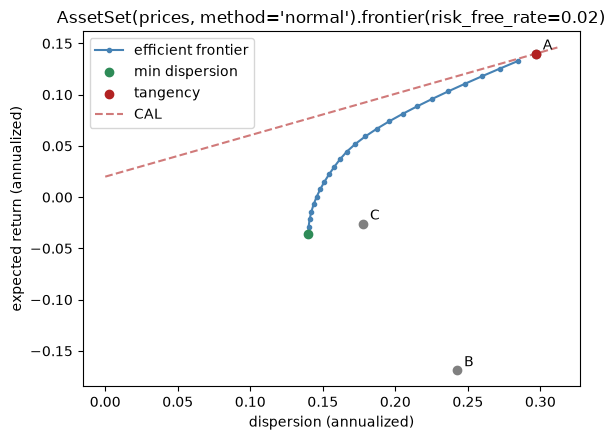

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(fr.curve["dispersion"], fr.curve["expected_return"], "o-", ms=3,
       color="steelblue", label="efficient frontier")
ax.scatter([fr.min_vol.dispersion], [fr.min_vol.expected_return],
          color="seagreen", zorder=5, label="min dispersion")
ax.scatter([fr.tangency.dispersion], [fr.tangency.expected_return],
          color="firebrick", zorder=5, label="tangency")
for a in aset.asset_points():
    ax.scatter([a["vol"]], [a["ret"]], color="gray", zorder=4)
    ax.annotate(a["ticker"], (a["vol"], a["ret"]), textcoords="offset points", xytext=(5, 3))

cal = fr.cal
ax.plot(cal["x"], cal["y"], "--", color="firebrick", alpha=0.6, label="CAL")

ax.set_xlabel("dispersion (annualized)")
ax.set_ylabel("expected return (annualized)")
ax.set_title("AssetSet(prices, method='normal').frontier(risk_free_rate=0.02)")
ax.legend()
fig.tight_layout()
plt.show()

In [20]:
mine = aset.portfolio({"A": 0.5, "B": 0.3, "C": 0.2}, label="Example mix")
print(mine)
mine.to_dict(rf)

Portfolio('Example mix', {'A': 0.5, 'B': 0.3, 'C': 0.2}, ret=0.0141, disp=0.1836)


{'weights': {'A': 0.5, 'B': 0.3, 'C': 0.2},
 'ret': 0.014142459352940215,
 'vol': 0.18364184983592094,
 'sharpe': -0.0318965456528201}

## Summary

| Story | Where it's pinned as a durable test |
|---|---|
| Hand arithmetic (mean / median / MAD / CoMAD) | `tests/test_verification.py::TestVsLegacy` (CoMAD tests) |
| Closed-form Markowitz min-variance / tangency | `tests/test_verification.py::TestClosedForm` |
| v2 vs. legacy (μ, Σ, portfolio perf, optimizers) | `tests/test_verification.py::TestVsLegacy` |
| Notebook golden numbers | `tests/test_verification.py::TestGoldenNotebook` |
| Object API == engine, number for number | `tests/test_model.py` |

Run `python -m pytest tests/` for the durable version of everything above.